# Notebook 1 — EDA & Data Prep

**Goal:** Load the HC3 corpus, unroll its paired Q&A structure into one row per text
sample, explore the data, choose the BERT/LSTM `max_length` from the token-length
distribution, and save the stratified train/val/test splits plus the cross-domain
evaluation sets that every later notebook consumes.

**Dataset:** [`Hello-SimpleAI/HC3`](https://huggingface.co/datasets/Hello-SimpleAI/HC3)
(CC-BY-SA-4.0) — the first large Human-vs-ChatGPT comparison corpus. We use the English
subsets only: `reddit_eli5` (training + in-domain test) and `finance` + `medicine`
(held out for the cross-domain experiment).

**Outputs written to `data/processed/`:**

| File | Contents |
|------|----------|
| `reddit_eli5_train.parquet` | 70% of unrolled reddit_eli5 |
| `reddit_eli5_val.parquet`   | 15% |
| `reddit_eli5_test.parquet`  | 15% (held-out in-domain test) |
| `finance_full.parquet`      | full unrolled finance subset (cross-domain) |
| `medicine_full.parquet`     | full unrolled medicine subset (cross-domain) |

Run top to bottom from a fresh kernel (**Kernel → Restart & Run All**).

## 1. Setup & imports

We seed **every** framework used across the project (Python `random`, NumPy, PyTorch +
MPS, TensorFlow, and HuggingFace) through a single `set_all_seeds(42)` helper, so results
are reproducible from a fresh kernel. The same helper is reused in every notebook.

Jupyter starts the kernel inside `notebooks/`, so we `chdir` up to the repo root once —
that lets every path in this project be written relative to the root
(`data/processed/...`, `models/...`) exactly as the later notebooks expect.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"        # quiet TensorFlow C++ logs
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import tensorflow as tf
import transformers
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, set_seed as hf_set_seed
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")               # keep committed output clean + free of env paths
transformers.logging.set_verbosity_error()      # silence the expected ">512 tokens" notice

# Run from the repo root so "data/processed/..." resolves the same here and in later notebooks.
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory:", Path.cwd().name)     # name only — no personal path in committed output


def set_all_seeds(seed: int = 42) -> None:
    """Seed every source of randomness used in this project."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    tf.random.set_seed(seed)
    hf_set_seed(seed)


set_all_seeds(42)
sns.set_theme(style="whitegrid")
print("Seeds set | pandas", pd.__version__, "| numpy", np.__version__, "| torch", torch.__version__)

Working directory: ai-generated-text-detector
Seeds set | pandas 2.3.3 | numpy 1.26.4 | torch 2.12.0


## 2. Load HC3

HC3 is a **paired** corpus: each raw row holds one `question` plus an array of
`human_answers` and an array of `chatgpt_answers` (GPT-3.5). Before modeling we must
flatten it into one row per individual answer with a binary label (`0` = human, `1` = AI).

The `load_and_unroll_hc3` helper below does exactly that flattening. First, though, we
load one subset raw and inspect a single example so the paired structure is visible.

In [2]:
def load_and_unroll_hc3(subset: str) -> pd.DataFrame:
    """
    Load one HC3 subset and unroll the paired structure into
    one row per (text, label) sample.

    Returns DataFrame with columns: text (str), label (int: 0=human, 1=ai), domain (str)
    """
    ds = load_dataset("Hello-SimpleAI/HC3", subset, split="train")
    rows = []
    for ex in ds:
        for ans in ex["human_answers"]:
            if ans and ans.strip():
                rows.append({"text": ans.strip(), "label": 0, "domain": subset})
        for ans in ex["chatgpt_answers"]:
            if ans and ans.strip():
                rows.append({"text": ans.strip(), "label": 1, "domain": subset})
    return pd.DataFrame(rows)

In [3]:
# Inspect the raw paired structure of one subset before unrolling.
raw_reddit = load_dataset("Hello-SimpleAI/HC3", "reddit_eli5", split="train")
print(raw_reddit)

ex = raw_reddit[0]
print("\nColumns:", list(ex.keys()))
print("Question:", ex["question"][:200])
print("# human answers :", len(ex["human_answers"]))
print("# chatgpt answers:", len(ex["chatgpt_answers"]))
print("\n--- first human answer ---\n", ex["human_answers"][0][:300])
print("\n--- first chatgpt answer ---\n", ex["chatgpt_answers"][0][:300])

Dataset({
    features: ['id', 'question', 'human_answers', 'chatgpt_answers'],
    num_rows: 17112
})

Columns: ['id', 'question', 'human_answers', 'chatgpt_answers']
Question: Why is every book I hear about a " NY Times # 1 Best Seller " ? ELI5 : Why is every book I hear about a " NY Times # 1 Best Seller " ? Should n't there only be one " # 1 " best seller ? Please explain
# human answers : 3
# chatgpt answers: 1

--- first human answer ---
 Basically there are many categories of " Best Seller " . Replace " Best Seller " by something like " Oscars " and every " best seller " book is basically an " oscar - winning " book . May not have won the " Best film " , but even if you won the best director or best script , you 're still an " oscar

--- first chatgpt answer ---
 There are many different best seller lists that are published by various organizations, and the New York Times is just one of them. The New York Times best seller list is a weekly list that ranks the best-selling books 

## 3. Unroll paired Q&A → per-sample rows

Apply the helper to all three subsets. `reddit_eli5` becomes the training + in-domain
test pool; `finance` and `medicine` are kept whole for the cross-domain experiment in
Notebook 4.

In [4]:
df_reddit   = load_and_unroll_hc3("reddit_eli5")   # training + in-domain test data
df_finance  = load_and_unroll_hc3("finance")       # cross-domain eval (Notebook 4)
df_medicine = load_and_unroll_hc3("medicine")      # cross-domain eval (Notebook 4)

print("unrolled shapes (rows, cols):")
print("  reddit_eli5:", df_reddit.shape)
print("  finance    :", df_finance.shape)
print("  medicine   :", df_medicine.shape)
df_reddit.head()

unrolled shapes (rows, cols):
  reddit_eli5: (67996, 3)
  finance    : (8436, 3)
  medicine   : (2582, 3)


,text,label,domain
0,"Basically there are many categories of "" Best ...",0,reddit_eli5
1,"If you 're hearing about it , it 's because it...",0,reddit_eli5
2,"One reason is lots of catagories . However , h...",0,reddit_eli5
3,There are many different best seller lists tha...,1,reddit_eli5
4,salt is good for not dying in car crashes and ...,0,reddit_eli5


## 4. EDA — row counts, label balance, text length

Three sanity checks before we commit to a split:

1. **Row counts** — confirm the unrolled sizes are in the expected ballpark
   (reddit ≫ finance > medicine).
2. **Label balance** — HC3 is ~75/25 human/AI.
   We'll note it in the README and switch on class weights when training.
3. **Text length** — raw character/word lengths, then a per-label histogram. This
   previews the token-length analysis that sets `max_length` in §5.

In [5]:
# 4a. Row counts per subset (after unrolling).
for name, d in [("reddit_eli5", df_reddit), ("finance", df_finance), ("medicine", df_medicine)]:
    print(f"{name:12s}: {len(d):>7,} samples")

reddit_eli5 :  67,996 samples
finance     :   8,436 samples
medicine    :   2,582 samples


In [6]:
# 4b. Label balance per subset (0 = human, 1 = AI). 
for name, d in [("reddit_eli5", df_reddit), ("finance", df_finance), ("medicine", df_medicine)]:
    counts = d["label"].value_counts().sort_index()
    pct = d["label"].value_counts(normalize=True).sort_index()
    print(f"{name:12s}  human={counts.get(0, 0):>6,} ({pct.get(0, 0):.1%})   "
          f"ai={counts.get(1, 0):>6,} ({pct.get(1, 0):.1%})")

reddit_eli5   human=51,336 (75.5%)   ai=16,660 (24.5%)
finance       human= 3,933 (46.6%)   ai= 4,503 (53.4%)
medicine      human= 1,248 (48.3%)   ai= 1,334 (51.7%)


> **⚠️ Finding — `reddit_eli5` is imbalanced: 75.5% human / 24.5% AI** (51,336 vs 16,660).
> An ELI5 question usually collects *several* human answers but only **one** ChatGPT
> answer, so unrolling produces a ~3:1 human:AI ratio — past the 60/40 threshold. Downstream
> models (LSTM, BERT) therefore use **class weights**, and we report **macro-F1** as the
> headline metric; TF-IDF + LogReg already sets `class_weight="balanced"`. `finance`
> (46.6/53.4) and `medicine` (48.3/51.7) are roughly balanced.

In [7]:
# 4c. Raw text-length distribution on the training subset (characters and words).
char_len = df_reddit["text"].str.len()
word_len = df_reddit["text"].str.split().str.len()
pd.DataFrame({"char_len": char_len, "word_len": word_len}).describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
)

,char_len,word_len
count,67996.000000,67996.000000
mean,744.708498,143.464880
std,750.107589,148.414135
min,23.000000,8.000000
50%,572.000000,112.000000
90%,1433.000000,269.000000
95%,1873.000000,371.000000
99%,3632.100000,730.050000
max,36793.000000,7904.000000


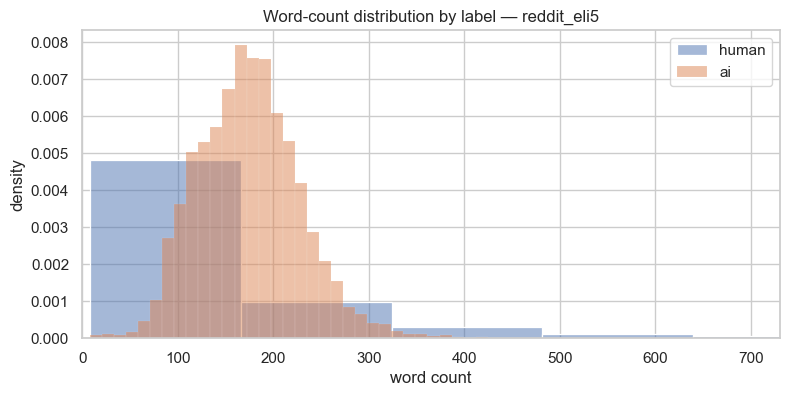

In [8]:
# 4d. Per-label word-count histogram. Helper is reused for any (df, col).
def plot_length_histogram(df, col="text", bins=50) -> None:
    """Overlay human vs AI word-count distributions for a text column."""
    lengths = df[col].str.split().str.len()
    plt.figure(figsize=(9, 4))
    for label, name in [(0, "human"), (1, "ai")]:
        sns.histplot(lengths[df["label"] == label], bins=bins, label=name,
                     alpha=0.5, stat="density")
    plt.xlim(0, lengths.quantile(0.99))
    plt.xlabel("word count")
    plt.ylabel("density")
    plt.title(f"Word-count distribution by label — {df['domain'].iloc[0]}")
    plt.legend()
    plt.show()


plot_length_histogram(df_reddit)

## 5. Token-length distribution → `max_length`

BERT and the LSTM operate on **WordPiece tokens**, not characters or words, so the only
length that matters for truncation is the BERT token count. We tokenize the training
texts with the real `bert-base-uncased` tokenizer and read off the distribution.

**Rule for choosing `max_length`:** `min(256, max(128, p95))` — two independent levers
with different jobs. `max(128, p95)` is the **coverage target** ("aim to keep the 95th
percentile of token lengths intact, but never go below 128"); `min(256, …)` is the
**compute ceiling** ("but never pay more than 256 tokens", since BERT's attention is
O(n²) and 512→256 quarters the attention cost — important on an M-series Mac). When the
two conflict, **the ceiling wins** and we accept whatever coverage that leaves. On this
dataset the 95th percentile is **408 tokens**, well above the 256 ceiling — so the ceiling
binds and the percentile never actually sets the value. The resulting coverage is read off
directly below (`pct_truncated`), not assumed from the percentile.

In [9]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Token length including [CLS]/[SEP]. Batch-encode (fast tokenizer) without truncation
# so we see the true distribution, then measure each sequence's length.
encoded = tokenizer(df_reddit["text"].tolist(), add_special_tokens=True, truncation=False)
token_lens = np.array([len(ids) for ids in encoded["input_ids"]])
print("Computed BERT token lengths for", len(token_lens), "reddit samples")

Computed BERT token lengths for 67996 reddit samples


50th percentile:    125 tokens
80th percentile:    237 tokens
85th percentile:    263 tokens
90th percentile:    304 tokens
95th percentile:    408 tokens
99th percentile:    795 tokens
max: 8753 tokens

95th pct = 408  ->  max_length = min(256, max(128, 95p)) = 256
samples longer than 256 tokens (would be truncated): 16.1%


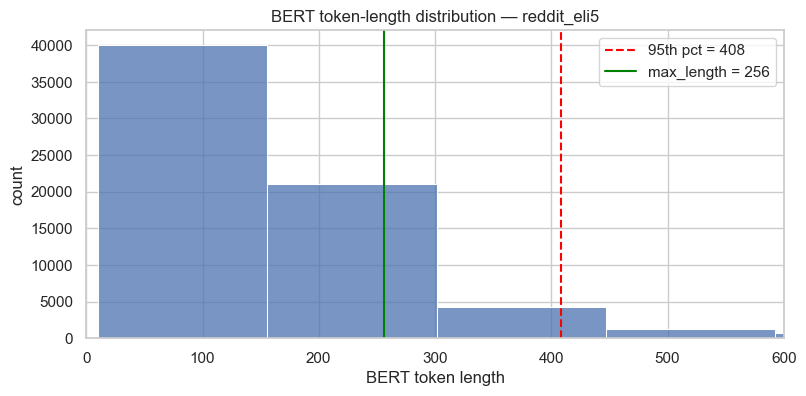

In [12]:
# Percentiles + the max_length rule, then visualize.
for p in [50, 80, 85, 90, 95, 99]:
    print(f"{p:>2}th percentile: {np.percentile(token_lens, p):6.0f} tokens")
print("max:", token_lens.max(), "tokens")

p95 = np.percentile(token_lens, 95)
# would like to cover 95% of samples without truncation
# but also enforce a reasonable max_length (at least 128, at most 256) for training efficiency and model limits.
# 128 <= max_length <= 256
recommended_max_length = int(min(256, max(128, round(p95))))
print(f"\n95th pct = {p95:.0f}  ->  max_length = min(256, max(128, 95p)) = {recommended_max_length}")

pct_truncated = (token_lens > recommended_max_length).mean()
print(f"samples longer than {recommended_max_length} tokens (would be truncated): {pct_truncated:.1%}")

plt.figure(figsize=(9, 4))
sns.histplot(token_lens, bins=60)
plt.axvline(p95, color="red", ls="--", label=f"95th pct = {p95:.0f}")
plt.axvline(recommended_max_length, color="green", ls="-", label=f"max_length = {recommended_max_length}")
plt.xlim(0, min(600, token_lens.max()))
plt.xlabel("BERT token length") 
plt.ylabel("count")
plt.title("BERT token-length distribution — reddit_eli5")
plt.legend()
plt.show()

### 🔒 EDA decisions (locked from the run above)

**`max_length = 256`.** The 95th-percentile BERT token length is **408**, above the 256
compute ceiling, so the ceiling binds: `min(256, max(128, 408)) = 256`. This leaves
**~84%** of samples fully intact and truncates the **16.1%** longer than 256 tokens —
note the coverage here is set by the *ceiling*, not by the 95th percentile, which never
took effect. The tradeoff is accepted because (a) the tail is long and thin (99th pct =
795 tokens, max = 8753) so chasing it would need 512+ tokens and ~4× the attention cost
for little gain, and (b) the human-vs-AI stylistic signal (hedging, structure, list
formatting) appears early and throughout the text, so truncating the tail rarely removes
the signal entirely. The same `max_length = 256` is reused **unchanged** in the LSTM
(Notebook 2), both BERT variants (Notebook 3), and `app.py`.

**Class imbalance → class weights + macro-F1.** `reddit_eli5` is **75.5% human / 24.5% AI**
(see §4), past the 60/40 threshold, so every trained model uses class weighting and the
headline metric is **macro-F1**, not accuracy.

## 6. Visual inspection — 5 human + 5 AI examples

A quick eyeball check that labels look right and to build intuition for the
human-vs-AI stylistic signal the models will learn (AI answers tend to be more
structured, evenly hedged, and list-friendly).

In [ ]:
pd.set_option("display.max_colwidth", 400)

#display as dataframe instead of list for better readability
print("=== 5 HUMAN (label 0) ===")
display(df_reddit[df_reddit["label"] == 0].sample(5, random_state=42)[["text"]])

print("=== 5 AI (label 1) ===")
display(df_reddit[df_reddit["label"] == 1].sample(5, random_state=42)[["text"]])

=== 5 HUMAN (label 0) ===


,text
11418,"Well , often times there is one or more specific signs for a proper noun . Houston for example , is signed by making the the "" H "" sign used in [ fingerspelling ] ( URL_1 ) and positioning it close to your face on the lower half of your face , as shown [ here ] ( URL_0 ) . Often times for names , people will be given a thing called a "" name - sign "" , which is a sign that represents a name . T..."
35078,"Basically , in the Middle East , you had the Tigris and Euphrates Rivers ( and the Nile ) which regularly flooded large flood plains . As populations grow , the amount of meat that can be hunted diminishes and if roving becomes impractical , growing crops becomes more important . Crops grown in the same fields year after year use up the nutrients . However river plains that flood annually repl..."
16282,"Because there really is n't a lot of value of a 4 hour flight from NY to London over an 8 hour one . Add in airport hassle and customs , and you are really looking at 6 hours vs. 10 . With the time change , you are pretty much wasting a day either way . And since it took about as much fuel as a 747 , with a quarter of the passengers , they had to charge 4 times as much to get there 4 hours soo..."
49649,"As a rule , your body knows best how to clean itself . Earwax is anti - bacterial and prevents the delicate skin in your ear canal from drying out and/or becoming infected . It is beneficial to have it inside your ear - canal . Of course , a normal level of ear - wax production will eventually push wax out of your ear canal , into your ear , where it is visible . Clean that out , it looks weir..."
28862,Spammers guess at your name and personal information to make it more likely you will look at their mail . In this case they are guessing wrong .


=== 5 AI (label 1) ===


,text
191,"When soldiers are killed in conflict, their weapons and gear are often collected and returned to their home country or military base. The weapons are typically taken out of service and either destroyed or stored for later use. The gear, such as clothing and other equipment, is also collected and either cleaned or repaired for reuse or discarded if it is not in good condition. \nIt is important..."
23215,"In the United States, the capital of a state is usually chosen by the state government and is often not the largest city in the state. There are a few reasons for this.\n\nFirst, the capital of a state is often chosen for its central location within the state. This makes it easier for people from all parts of the state to travel to the capital for business or to participate in the state's gove..."
30115,"When concrete is mixed, water is added to a dry mixture of cement, sand, and aggregate (such as rocks or gravel). The water is mixed with the dry ingredients to create a slurry, or a thin mixture that can be poured and shaped.After the concrete has been poured and has hardened, the water that was used in the mixing process is no longer needed. It becomes trapped within the hardened concrete an..."
8399,"It's not accurate to say that the tribes of Africa or any other group of people have developed less technology than others. Different groups of people have developed different technologies at different times in history, and this has often been influenced by a variety of factors such as the resources available to them, the challenges they faced, and the cultural and social practices of their so..."
23523,"Bad words, also known as swear words or curses, are words that some people consider to be rude, offensive, or inappropriate. These words are often used to express strong emotions, such as anger or frustration, and can be hurtful or disrespectful to other people if used in the wrong way.\n\nSome people use bad words because they are upset or angry and want to vent their emotions, or because the..."


## 7. Stratified 70/15/15 split (reddit_eli5)

A held-out **test** set (not just train/val) is what lets every model be compared on
identical, never-seen data. We split in two stages — peel off 15% test, then split the
rest into train/val — stratifying on the label both times so each split keeps the same
label ratio as the full set (here ≈75/25 human/AI, not 50/50 — see §4). `random_state=42`
makes the split reproducible.

`finance` and `medicine` are **not** split: they are kept whole as out-of-domain test
sets for Notebook 4.

In [13]:
def stratified_split(df, label_col="label", sizes=(0.70, 0.15, 0.15), seed=42):
    """
    Two-stage split: first split off test (15%), then split remaining
    into train (70/85 ≈ 82.4%) and val (15/85 ≈ 17.6%).
    """
    assert abs(sum(sizes) - 1.0) < 1e-9
    train_val, test = train_test_split(
        df, test_size=sizes[2], stratify=df[label_col], random_state=seed
    )
    val_size_rel = sizes[1] / (sizes[0] + sizes[1])
    train, val = train_test_split(
        train_val, test_size=val_size_rel, stratify=train_val[label_col], random_state=seed
    )
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)


train_df, val_df, test_df = stratified_split(df_reddit)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    bal = d["label"].value_counts(normalize=True).sort_index()
    print(f"{name:5s}: {len(d):>7,} rows | human {bal.get(0, 0):.1%} / ai {bal.get(1, 0):.1%}")

train:  47,596 rows | human 75.5% / ai 24.5%
val  :  10,200 rows | human 75.5% / ai 24.5%
test :  10,200 rows | human 75.5% / ai 24.5%


## 8. Save splits + cross-domain sets to `data/processed/`

Persist everything as Parquet (columnar, compressed, preserves dtypes). These five files
are the contract every downstream notebook loads — Notebook 2/3 read the reddit splits,
Notebook 4 reads the reddit test split plus the finance/medicine sets.

In [47]:
out_dir = Path("data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

artifacts = {
    "reddit_eli5_train.parquet": train_df,
    "reddit_eli5_val.parquet": val_df,
    "reddit_eli5_test.parquet": test_df,
    "finance_full.parquet": df_finance,
    "medicine_full.parquet": df_medicine,
}
for fname, d in artifacts.items():
    path = out_dir / fname
    d.to_parquet(path, index=False)
    print(f"saved {fname:26s} {len(d):>7,} rows  ({path.stat().st_size / 1e6:5.1f} MB)")

print("\nDone. Cross-check the saved sizes against the 50MB GitHub threshold before committing.")

saved reddit_eli5_train.parquet   47,596 rows  ( 20.8 MB)
saved reddit_eli5_val.parquet     10,200 rows  (  4.4 MB)
saved reddit_eli5_test.parquet    10,200 rows  (  4.4 MB)
saved finance_full.parquet         8,436 rows  (  4.9 MB)
saved medicine_full.parquet        2,582 rows  (  1.1 MB)

Done. Cross-check the saved sizes against the 50MB GitHub threshold before committing.


## Next steps

- Confirm the printed file sizes; any Parquet over ~50 MB is gitignored and lives on
  HF Hub instead (the small ones commit to GitHub).
- Carry the locked `max_length` from §5 into Notebook 2 (LSTM) and Notebook 3 (BERT)
  unchanged.
- Proceed to `02_baselines_tfidf_lstm.ipynb`.